In [17]:
!git clone https://github.com/solamar2/Brain-Tumor-MRI---DETR

Cloning into 'Brain-Tumor-MRI---DETR'...
remote: Enumerating objects: 13150, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 13150 (delta 7), reused 8 (delta 3), pack-reused 13136 (from 1)
Receiving objects: 100% (13150/13150), 144.71 MiB | 13.59 MiB/s, done.
Resolving deltas: 100% (36/36), done.
Updating files: 100% (15757/15757), done.


In [26]:
%cd Brain-Tumor-MRI---DETR
!git pull

[Errno 2] No such file or directory: 'Brain-Tumor-MRI---DETR'
/content/Brain-Tumor-MRI---DETR/Brain-Tumor-MRI---DETR/Brain-Tumor-MRI---DETR
Already up to date.


In [27]:
from scripts.EDA import BrainTumorEDA
from scripts.segmentation import BrainMaskSimple
from scripts.preprocessing import BrainTumorDataset
from scripts.dataloader import BrainTumorDataLoader
from scripts.detection_model_DETR import DETRTrainer
import torch
import os
import random

main_path = os.getcwd()
main_train_path= os.path.join(main_path, 'data/Train')
main_test_path = os.path.join(main_path, "data/Test")

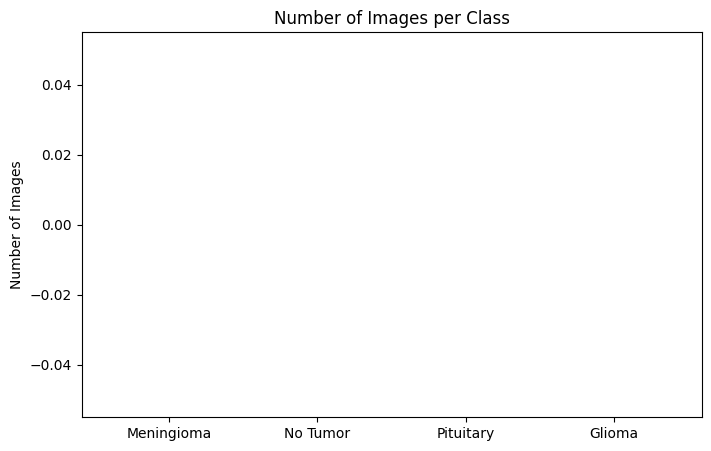

<Figure size 1000x800 with 0 Axes>

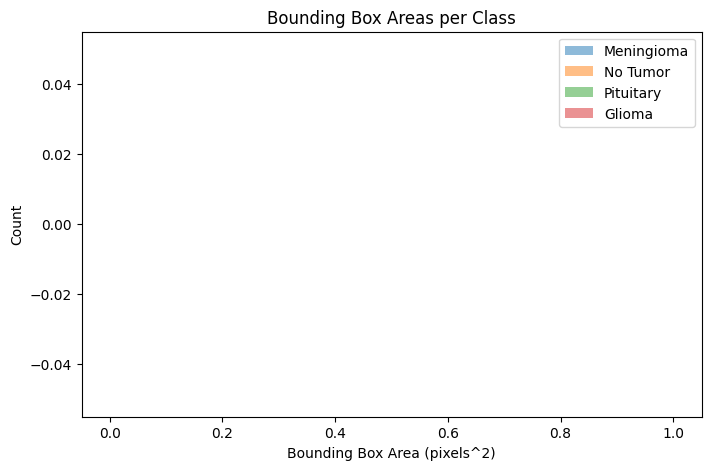

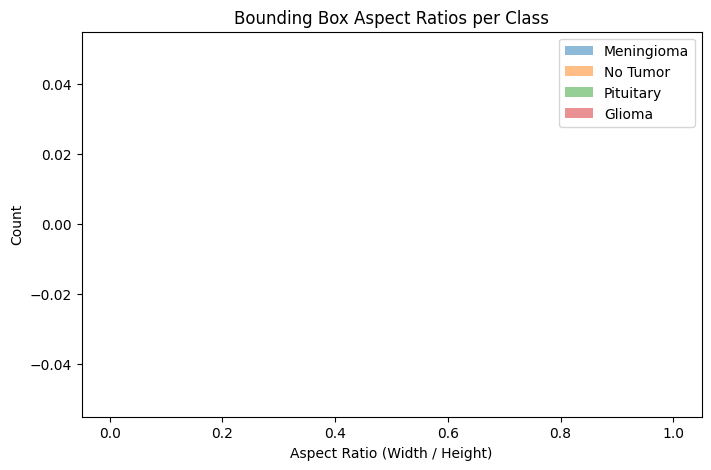

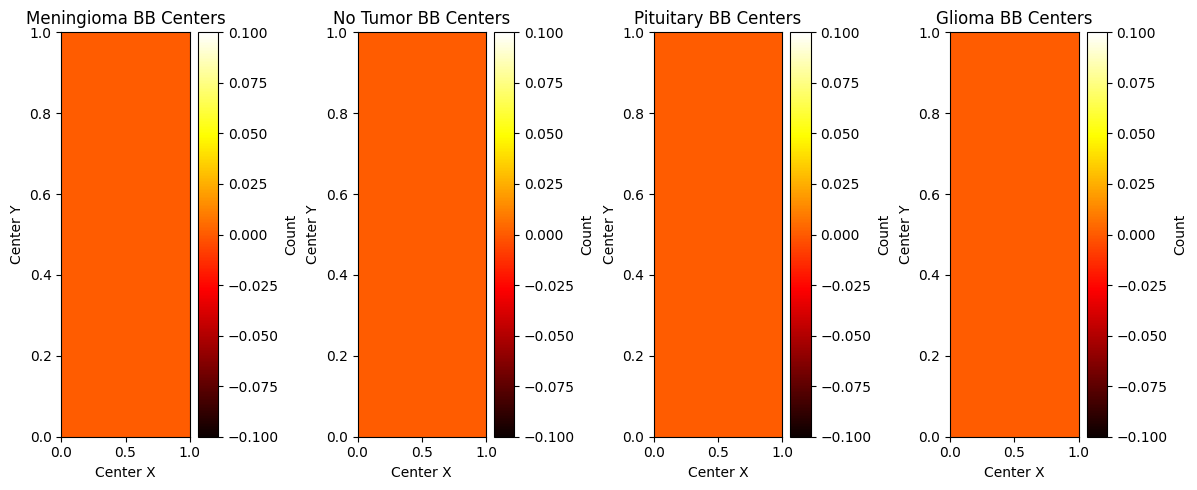

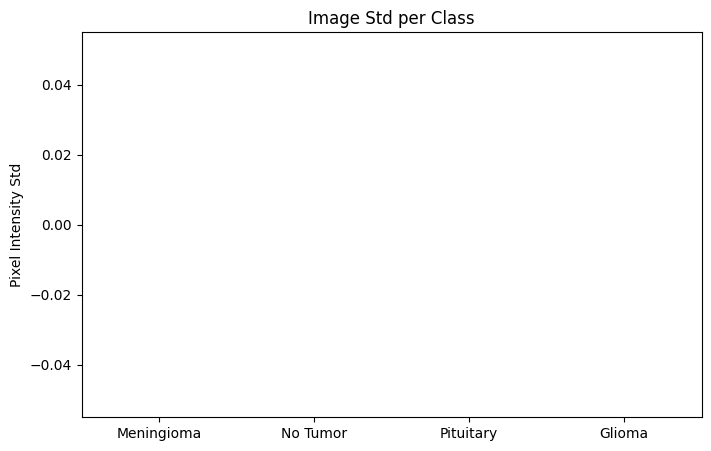

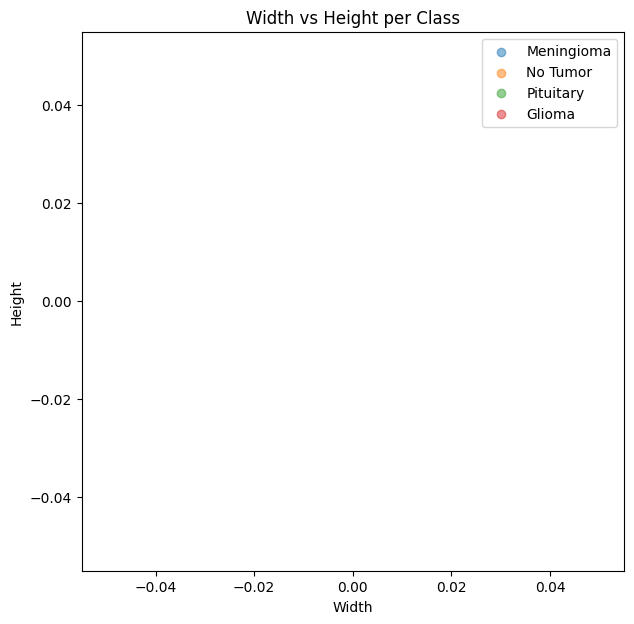

In [20]:
# ------------------------------
## 0. EDA:
eda = BrainTumorEDA(main_train_path)
eda.plot_class_counts_and_examples()
eda.plot_bb_analysis()
eda.plot_image_stats()


Masks saved: Meningioma
Masks saved: No Tumor
Masks saved: Pituitary
Masks saved: Glioma


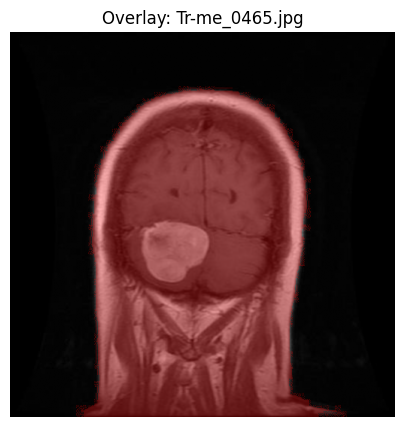

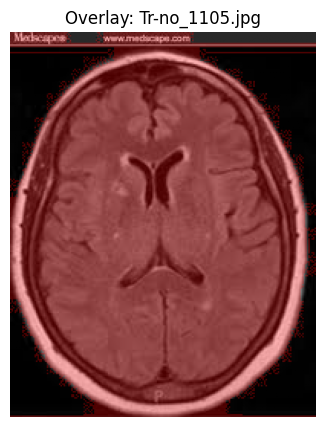

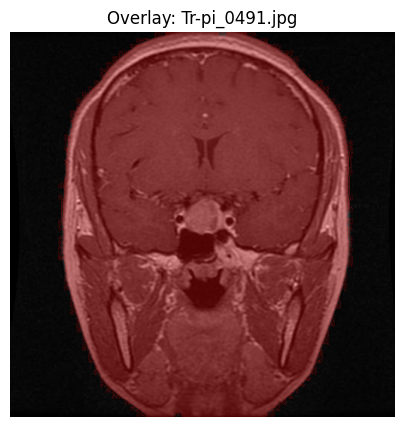

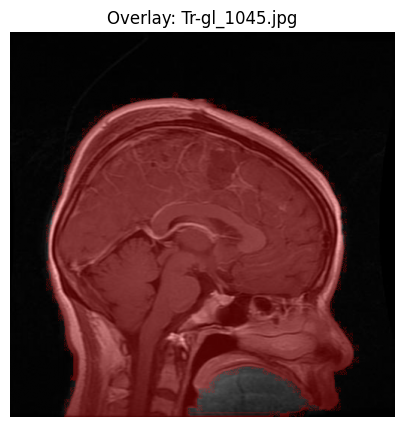

In [21]:
# ------------------------------
## 1. Segment brain vs background
# Collect class dirs that need segmentation
segmenter = BrainMaskSimple(train_dir=main_train_path)
segmenter.run()

# Random visualization (one image per class)
for cls_name in os.listdir(main_train_path):
    cls_dir = os.path.join(main_train_path, cls_name)
    images_dir = os.path.join(cls_dir, "images")
    masks_dir = os.path.join(cls_dir, "brain_masks")
    if not os.path.exists(images_dir) or not os.path.exists(masks_dir):
        continue

    img_file = random.choice([f for f in os.listdir(images_dir) if f.endswith(".jpg")])
    img_path = os.path.join(images_dir, img_file)
    mask_path = os.path.join(masks_dir, img_file)
    segmenter.create_overlay(img_path, mask_path, alpha=0.3)


In [22]:
# ------------------------------
# Class to idx: (same to train and test)
class_names = sorted([d for d in os.listdir(main_train_path) if os.path.isdir(os.path.join(main_train_path, d))])
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
num_classes = len(class_names)

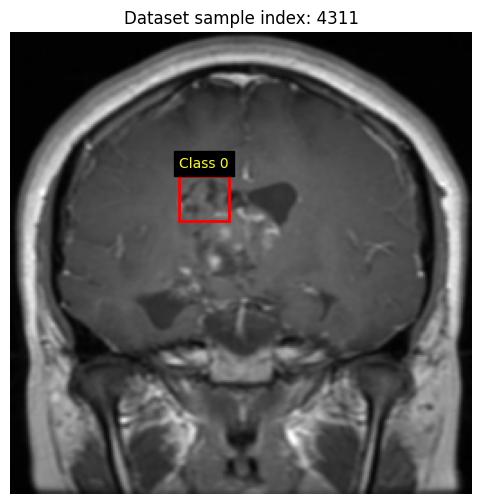

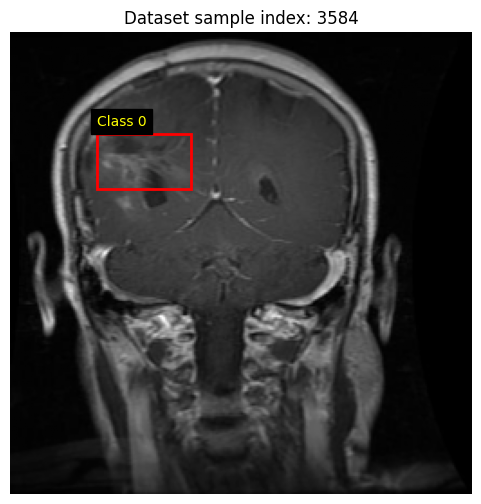

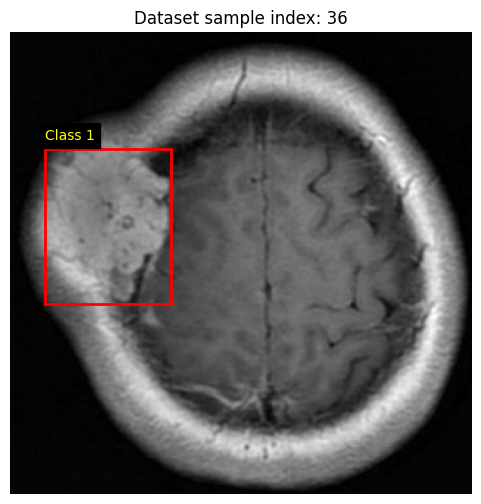

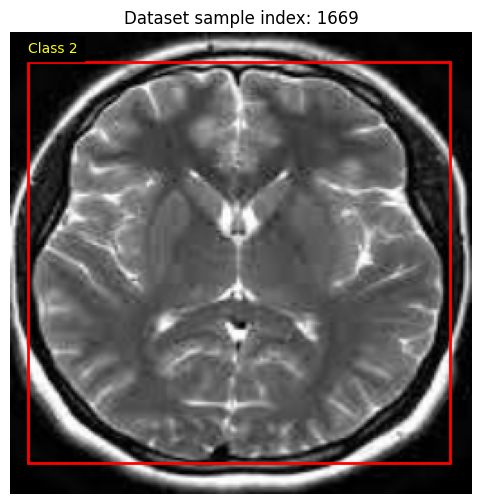

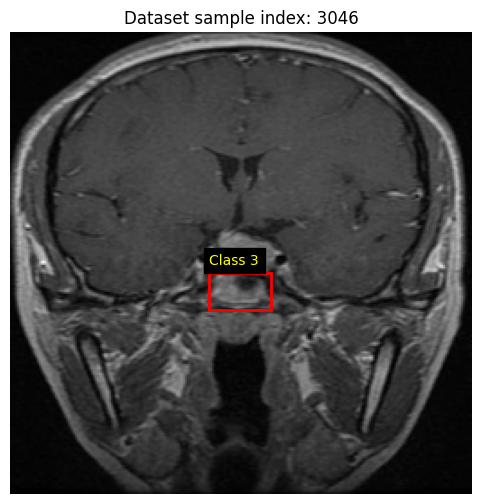

In [23]:
# ------------------------------
## 2. Pre process the data
train_dataset = BrainTumorDataset(main_train_path, class_to_idx, image_size=(256, 256), augment=True)
for i in range (0,5):
    train_dataset.visualize_sample()

In [24]:
# ------------------------------
## 3. Dataloader
train_loader = BrainTumorDataLoader(train_dataset, class_to_idx, batch_size=4, weighted_sampling=True).get_loader()

In [29]:
# ------------------------------
# 4. Train model
device = "cuda" if torch.cuda.is_available() else "cpu"
trainer = DETRTrainer(num_classes=num_classes, device=device, learning_rate=1e-3, weight_decay=1e-4, num_epochs=50, BB_weight=1.0)
trainer.train(train_loader, print_every=1)

TypeError: DETRTrainer.__init__() got an unexpected keyword argument 'BB_weight'

In [ ]:
# ------------------------------
# 5. Test:
segmenter = BrainMaskSimple(train_dir=main_test_path)
segmenter.run()
test_dataset  = BrainTumorDataset(main_test_path,  class_to_idx, image_size=(256, 256), augment=False)
test_loader  = BrainTumorDataLoader(test_dataset,  class_to_idx, batch_size=4, weighted_sampling=False, shuffle=False).get_loader()

all_results = []
for imgs, targets in test_loader:
    imgs_tensor = torch.stack(imgs).to(device)  # [B,C,H,W]
    batch_results = trainer.predict(imgs_tensor, conf_thresh=0.5)
    all_results.extend(batch_results)

DETRTrainer.visualize_prediction(train_dataset, trainer, idx=5, dataset_type="Train")
DETRTrainer.visualize_prediction(test_dataset, trainer, idx=2, dataset_type="Test")
